## **Stock Price Analysis, Forecasting & Prediction**

Install and import libraries

In [1]:
!pip install -q yfinance pmdarima prophet plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from prophet import Prophet

In [4]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM,Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from joblib import dump
import json as json_lib

np.random.seed(42)

**Download data**

10 years of daily data for AAPL, ending on 2026-08-02 (today's date) auto_adjust=True gives split/dividend-adjusted prices, which is standard for price forecasting.

In [5]:
TICKER = "AAPL"
END_DATE = "2026-08-02"
START_DATE = "2016-08-02"   #exactly 10 years back

raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
#Flatten yfinance's multiindex columns (Price, Ticker)> just Price
if isinstance(raw.columns, pd.MultiIndex):
  raw.columns = raw.columns.get_level_values(0)

raw = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
raw.index.name = "Date"

print(raw.shape)
raw.head()

[*********************100%***********************]  1 of 1 completed

(2513, 5)


Price,Open,High,Low,Close,Volume
Date,,,,,
2016-08-02,24.121441,24.125990,23.655161,23.764339,135266400
2016-08-03,23.839393,24.073669,23.830294,24.062298,120810400
2016-08-04,24.144634,24.240681,24.076027,24.210953,109634800
2016-08-05,24.302412,24.617999,24.281831,24.579123,162213600
2016-08-08,24.588285,24.782669,24.505960,24.782669,112148800


In [6]:
raw.tail()

Price,Open,High,Low,Close,Volume
Date,,,,,
2026-07-27,334.251737,339.277401,333.732166,336.619690,49604300
2026-07-28,339.736982,342.594533,335.310806,339.786926,51859000
2026-07-29,339.437272,344.273097,337.059318,337.898590,56090800
2026-07-30,332.812967,334.461540,329.305982,333.142670,74817800
2026-07-31,304.547356,310.422294,299.741503,308.643829,132489100


In [7]:
# Basic Sanity checks
print("Missing values per column:")
print(raw.isnull().sum())
print("\nDate range:", raw.index.min(), "to", raw.index.max())
print("Any duplicate dates:", raw.index.duplicated().sum())

Missing values per column:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Date range: 2016-08-02 00:00:00 to 2026-07-31 00:00:00
Any duplicate dates: 0


In [8]:
print(raw.dtypes)

Price
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object


**Exploratory Data Analysis (EDA)**

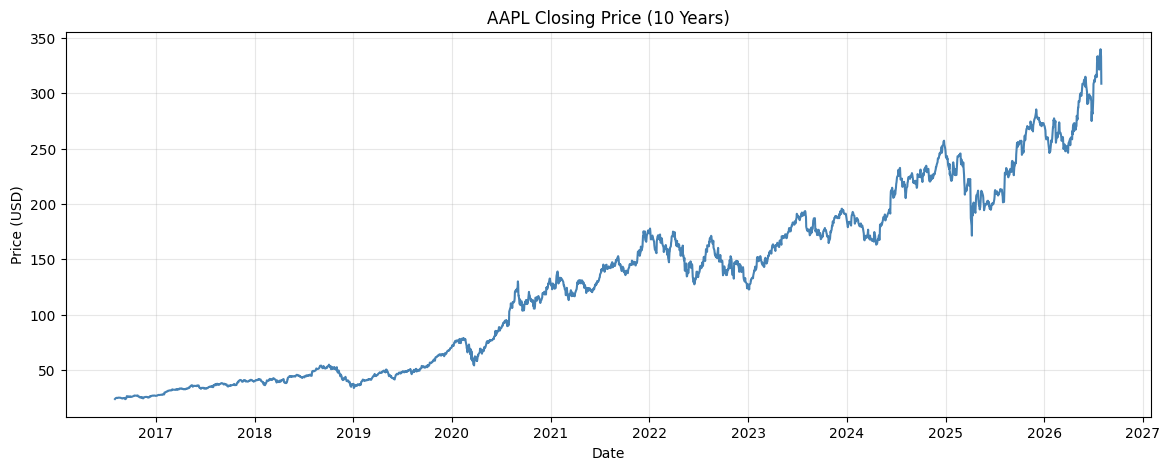

In [9]:
plt.figure(figsize=(14,5))
plt.plot(raw.index, raw["Close"], color='steelblue')
plt.title(f"{TICKER} Closing Price (10 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(alpha= 0.3)
plt.show()

In [10]:
fig = go.Figure(data=[go.Candlestick(
    x=raw.index, open=raw['Open'], high=raw["High"], low=raw["Low"], close=raw["Close"]
)])
fig.update_layout(title=f"{TICKER} Candlestick Chart", xaxis_title="Date", yaxis_title="Price (USD)",
                  xaxis_rangeslider_visible=False, template="plotly_dark")
fig.show()

In [11]:
#Moving Averages
raw["MA_20"] = raw["Close"].rolling(20).mean()  # 20 Day Moving Average
raw["MA_50"] = raw["Close"].rolling(50).mean()  # 50 Day Moving Average

fig = go.Figure()
fig.add_trace(go.Scatter(x=raw.index, y=raw["Close"], name="Close", line=dict(color="blue", width=1)))
fig.add_trace(go.Scatter(x=raw.index, y=raw["MA_20"], name="20-Day MA", line=dict(color="orange", width=1)))
fig.add_trace(go.Scatter(x=raw.index, y=raw["MA_50"], name="50-Day MA", line=dict(color="red", width=1)))
fig.update_layout(title=f"{TICKER} Price with Moving Averages", xaxis_title="Date", yaxis_title="Price (USD)",
                   template="plotly_dark")
fig.show()

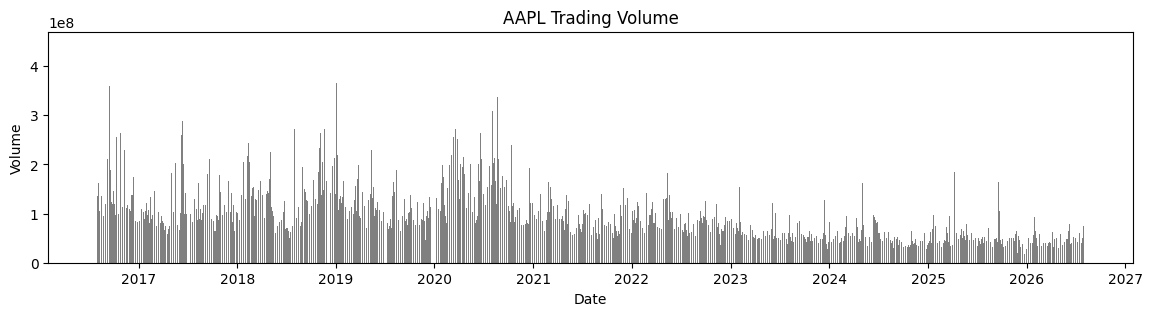

In [12]:
plt.figure(figsize=(14,3))
plt.bar(raw.index, raw["Volume"], color="grey", width=1)
plt.title(f"{TICKER} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

**Stationarity checks and decomposition**


Stock prices are almost always non-stationary (they trend). We confirm this with the Augmented Dickey-Fuller
test.

In [14]:
def adf_test(series, name=""):
  result = adfuller(series.dropna())
  print(f"--- ADF Test: {name} ---")
  print(f"ADF Statistics: {result[0]:.4f}")
  print(f"p-value: {result[1]:.6f}")
  for key, value in result[4].items():
    print(f"Critical Value ({key}): {value:.3f}")
  verdict = "STATIONARY" if result[1] <= 0.05 else "NOT STATIONARY"
  print(f"Verdict: {verdict}\n")
  return result[1] <= 0.05

adf_test(raw["Close"], "Raw Close Price")

log_returns = np.log(raw["Close"]).diff().dropna()
adf_test(log_returns, "Log Returns (differenced)")

--- ADF Test: Raw Close Price ---
ADF Statistics: 0.3432
p-value: 0.979243
Critical Value (1%): -3.433
Critical Value (5%): -2.863
Critical Value (10%): -2.567
Verdict: NOT STATIONARY

--- ADF Test: Log Returns (differenced) ---
ADF Statistics: -16.4255
p-value: 0.000000
Critical Value (1%): -3.433
Critical Value (5%): -2.863
Critical Value (10%): -2.567
Verdict: STATIONARY



np.True_

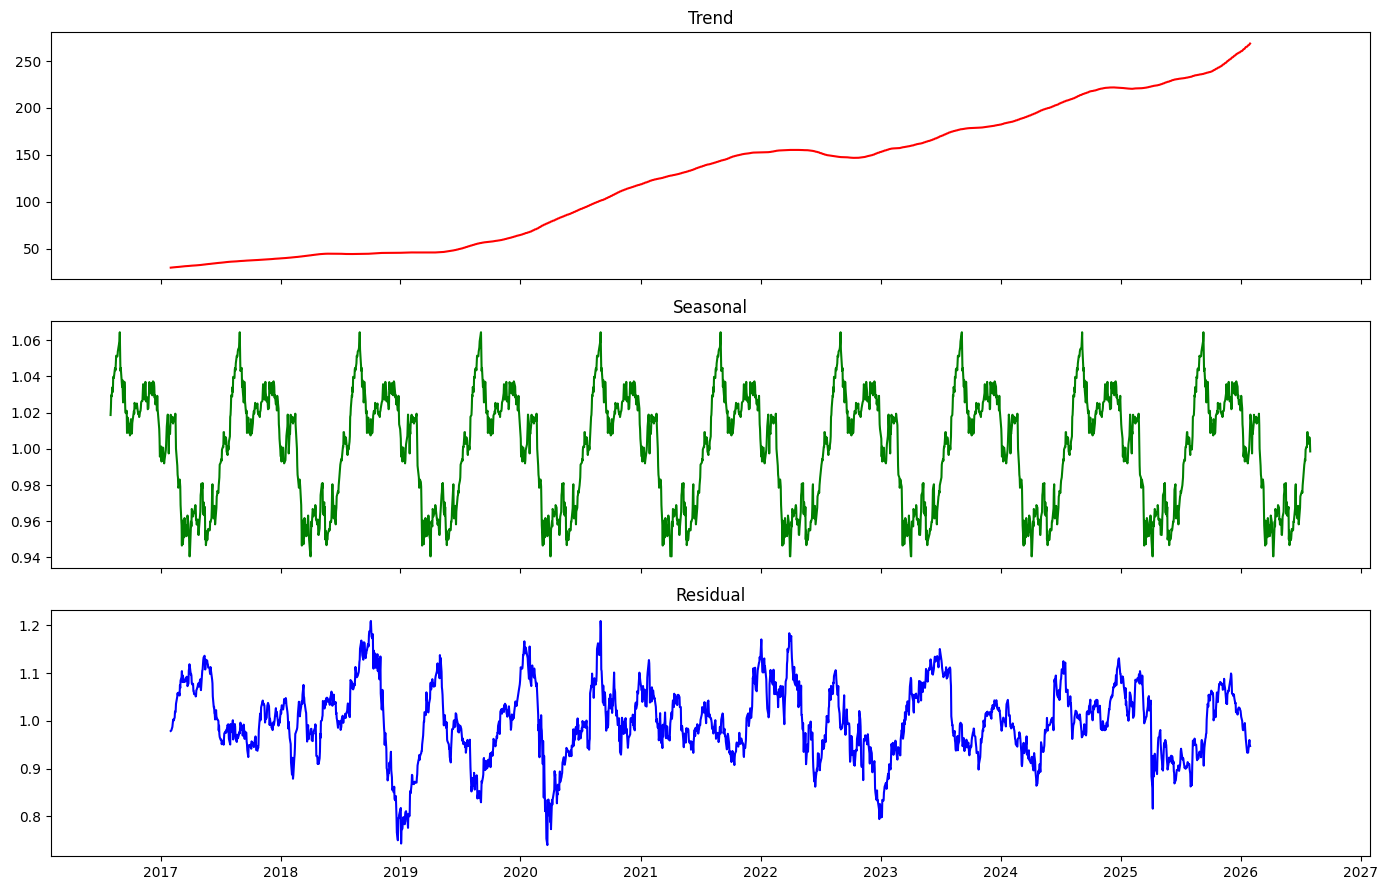

In [15]:
decomp = seasonal_decompose(raw["Close"], model="multiplicative", period=252)  # from statsmodel.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(3,1, figsize=(14, 9), sharex=True)
axes[0].plot(decomp.trend, color="red"); axes[0].set_title("Trend")
axes[1].plot(decomp.seasonal, color="green"); axes[1].set_title("Seasonal")
axes[2].plot(decomp.resid, color="blue"); axes[2].set_title("Residual")
plt.tight_layout()
plt.show()

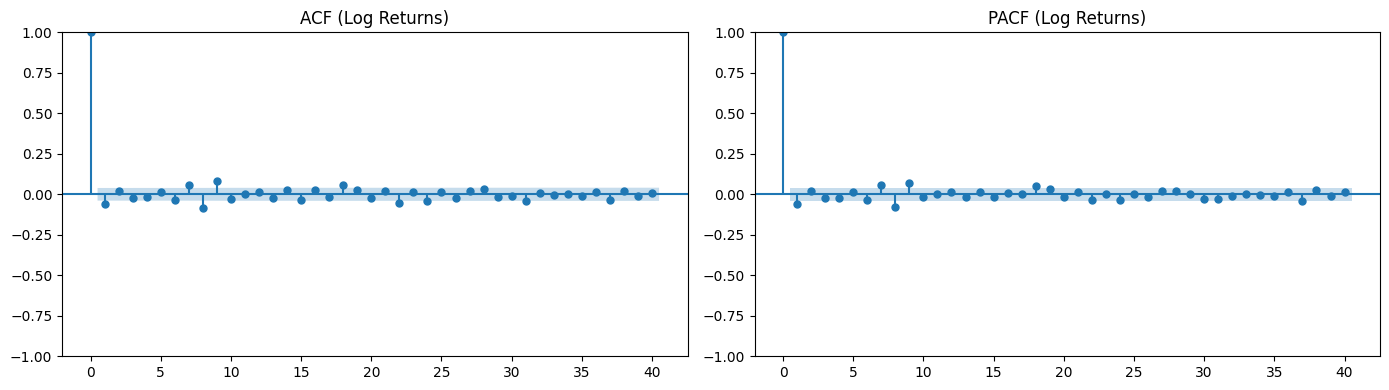

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(log_returns, ax=axes[0], lags=40); axes[0].set_title("ACF (Log Returns)")
plot_pacf(log_returns, ax=axes[1], lags=40); axes[1].set_title("PACF (Log Returns)")
plt.tight_layout()
plt.show()

**Train/Test split — used identically by every model**

In [17]:
SPLIT_RATIO = 0.8
split_idx = int(len(raw) * SPLIT_RATIO)

train_df = raw.iloc[:split_idx].copy()
test_df  = raw.iloc[split_idx:].copy()

print(f"Train: {train_df.index.min().date()} to {train_df.index.max().date()}  ({len(train_df)} rows)")
print(f"Test:  {test_df.index.min().date()} to {test_df.index.max().date()}  ({len(test_df)} rows)")

Train: 2016-08-02 to 2024-07-29  (2010 rows)
Test:  2024-07-30 to 2026-07-31  (503 rows)


**train_test_split()**, By default, it shuffles the data. For time series, that is not appropriate because it mixes past and future observations.

In [18]:
# Shared evaluation helper -> every model logs into this same dict, in the same $ scale
results = {}

def evaluate_forecast(actual, predicted, model_name):
    actual = np.asarray(actual).flatten()
    predicted = np.asarray(predicted).flatten()
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    results[model_name] = {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape}
    print(f"{model_name:20s} | MAE: {mae:8.3f}  RMSE: {rmse:8.3f}  MAPE: {mape:6.3f}%")
    return mae, rmse, mape

**Naive Baseline**

In [19]:
naive_preds = np.concatenate([[train_df["Close"].iloc[-1]], test_df["Close"].values[:-1]])
evaluate_forecast(test_df["Close"].values, naive_preds, "Naive Baseline")

Naive Baseline       | MAE:    2.907  RMSE:    4.291  MAPE:  1.204%


(2.9066993910560077,
 np.float64(4.29095930294976),
 np.float64(1.203867964816229))

**ARIMA**

In [20]:
arima_model = auto_arima(train_df["Close"], seasonal = False, trace=True,
                         error_action="ignore",supress_warnings=True)
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.49 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8555.896, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8557.111, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8557.073, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8558.351, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=8559.419, Time=0.38 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 3.233 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2010
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4275.948
Date:                Sun, 16 Aug 2026   AIC                           8555.896
Time:                        13:36:43   BIC                           8567.107
Sample:                             0   HQIC                          8560.012
               

In [21]:
arima_forecast = arima_model.predict(n_periods=len(test_df))
evaluate_forecast(test_df["Close"].values, arima_forecast, "ARIMA")

ARIMA                | MAE:   19.026  RMSE:   24.593  MAPE:  7.735%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



(19.025503737494404,
 np.float64(24.59329411520205),
 np.float64(7.735173769969397))

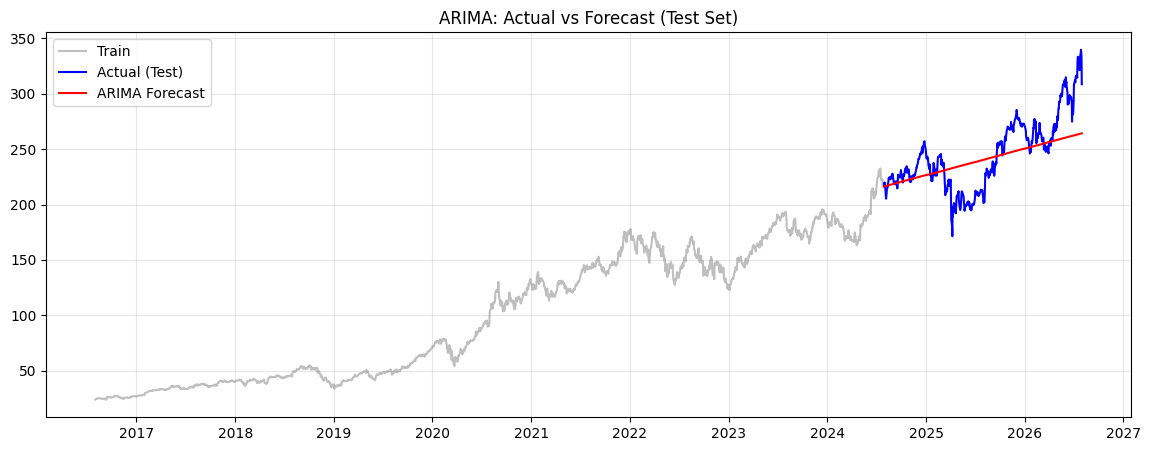

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(train_df.index, train_df["Close"], label="Train", color="grey", alpha=0.5)
plt.plot(test_df.index, test_df["Close"], label="Actual (Test)", color="blue")
plt.plot(test_df.index, arima_forecast, label="ARIMA Forecast", color="red")
plt.title("ARIMA: Actual vs Forecast (Test Set)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**SARIMAX**

In [23]:
sarimax_auto = auto_arima(train_df["Close"], seasonal=True, m=5, trace=True,
                          error_action="ignore", suppress_warnings=True,
                          stepwise=True, max_order=None)
print(sarimax_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=8562.726, Time=3.68 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=8555.896, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=8558.072, Time=0.46 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=8557.986, Time=0.86 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=8558.351, Time=0.10 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=8556.846, Time=0.41 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=8556.794, Time=0.25 sec
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=8556.760, Time=0.66 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=8557.111, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[5] intercept   : AIC=8557.073, Time=0.16 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=8559.419, Time=0.38 sec

Best model:  ARIMA(0,1,0)(0,0,0)[5] intercept
Total fit time: 7.178 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2

In [24]:
sarimax_forecast = sarimax_auto.predict(n_periods=len(test_df))
evaluate_forecast(test_df["Close"].values, sarimax_forecast, "SARIMAX")

SARIMAX              | MAE:   19.026  RMSE:   24.593  MAPE:  7.735%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



(19.025503737494404,
 np.float64(24.59329411520205),
 np.float64(7.735173769969397))

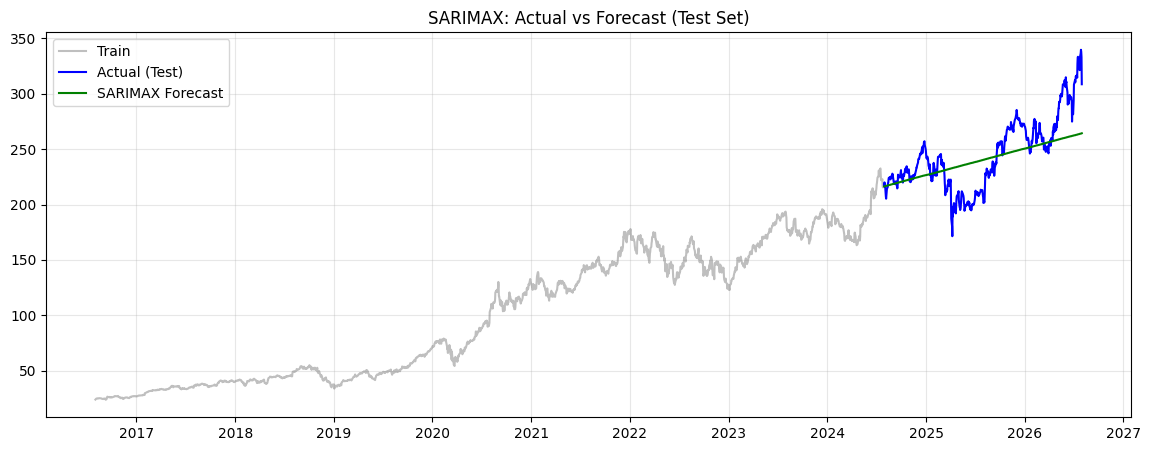

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(train_df.index, train_df["Close"], label="Train", color="grey", alpha=0.5)
plt.plot(test_df.index, test_df["Close"], label="Actual (Test)", color="blue")
plt.plot(test_df.index, sarimax_forecast, label="SARIMAX Forecast", color="green")
plt.title("SARIMAX: Actual vs Forecast (Test Set)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [26]:
# Residual diagnostics on the SARIMAX model (Ljung-Box: p > 0.05 means residuals look like white noise)
residuals = pd.Series(sarimax_auto.resid())
ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(ljung_box)

      lb_stat  lb_pvalue
10  16.786689   0.079219


**LSTM**

In [27]:
N_STEPS = 100 # How many past days the model looks at to predict the next day

train_close = train_df[["Close"]].values
test_close = test_df[["Close"]].values

scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(train_close)          #fit on train data only

train_scaled = scaler.transform(train_close)
test_scaled = scaler.transform(test_close)

def create_sequences(scaled_series, n_steps):
  X, y = [], []
  for i in range(n_steps, len(scaled_series)):
    X.append(scaled_series[i - n_steps:i, 0])
    y.append(scaled_series[i, 0])
  return np.array(X), np.array(y)

X_train_full, y_train_full = create_sequences(train_scaled, N_STEPS)
# To generate test-set predictions we need the N_STEPS days *before* each test day.
# Prepending the tail of TRAIN is standard practice and introduces no leakage: every
# prediction for a test day only uses information strictly before that day.
combined_scaled = np.concatenate([train_scaled[-N_STEPS:], test_scaled], axis=0)
X_test, y_test = create_sequences(combined_scaled, N_STEPS)

# Carve a validation set out of TRAIN only (last 10%)
val_cut = int(len(X_train_full) * 0.9)
X_tr, X_val = X_train_full[:val_cut], X_train_full[val_cut:]
y_tr, y_val = y_train_full[:val_cut], y_train_full[val_cut:]

X_tr  = X_tr.reshape((X_tr.shape[0], X_tr.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Train shape:", X_tr.shape, " Val shape:", X_val.shape, " Test shape:", X_test.shape)

Train shape: (1719, 100, 1)  Val shape: (191, 100, 1)  Test shape: (503, 100, 1)


In [29]:
def build_lstm(n_steps):
    model = Sequential([
        Input(shape=(n_steps, 1)),
        LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        LSTM(32, return_sequences=False, kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(16, activation="relu", kernel_regularizer=l2(0.001)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mean_squared_error")
    return model

In [30]:
lstm_model = build_lstm(N_STEPS)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

history = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),    # validation from TRAIN tail, not from test
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 0.1003 - val_loss: 0.0694 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0541 - val_loss: 0.0430 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0351 - val_loss: 0.0366 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0255 - val_loss: 0.0247 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.0196 - val_loss: 0.0270 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0160 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0132 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0111 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 9/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0098 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 10/1

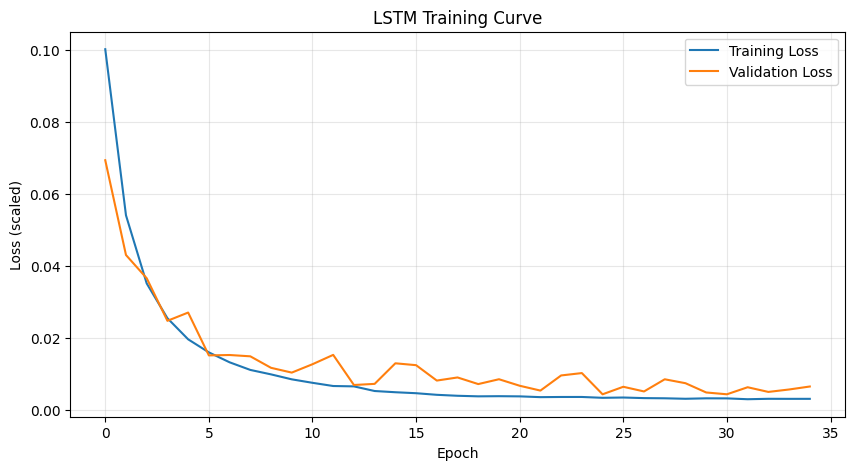

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Curve"); plt.xlabel("Epoch"); plt.ylabel("Loss (scaled)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [33]:
# Predict on test set, then inverse-transform back to dollars before scoring
test_preds_scaled = lstm_model.predict(X_test, verbose=0)
test_preds_dollars = scaler.inverse_transform(test_preds_scaled).flatten()
test_actual_dollars = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

evaluate_forecast(test_actual_dollars, test_preds_dollars, "LSTM")

LSTM                 | MAE:   16.590  RMSE:   20.724  MAPE:  6.423%


(16.590480159812607,
 np.float64(20.724147159844378),
 np.float64(6.422564580161065))

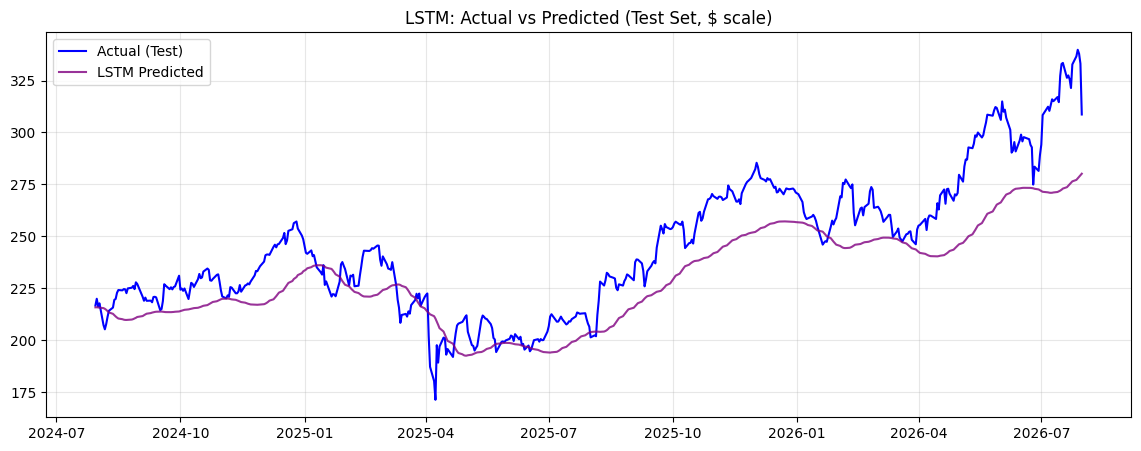

In [34]:
plt.figure(figsize=(14, 5))
plt.plot(test_df.index[-len(test_actual_dollars):], test_actual_dollars, label="Actual (Test)", color="blue")
plt.plot(test_df.index[-len(test_preds_dollars):], test_preds_dollars, label="LSTM Predicted", color="purple", alpha=0.8)
plt.title("LSTM: Actual vs Predicted (Test Set, $ scale)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Facebook Prophet Model**

In [36]:
prophet_train = train_df.reset_index()[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})
prophet_test = test_df.reset_index()[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})

prophet_model =Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
prophet_model.fit(prophet_train)

prophet_forecast = prophet_model.predict(prophet_test[["ds"]])
evaluate_forecast(prophet_test["y"].values, prophet_forecast["yhat"].values, "Prophet")

Prophet              | MAE:   18.881  RMSE:   22.631  MAPE:  7.753%


(18.880846856937506,
 np.float64(22.6305917101119),
 np.float64(7.753138753758557))

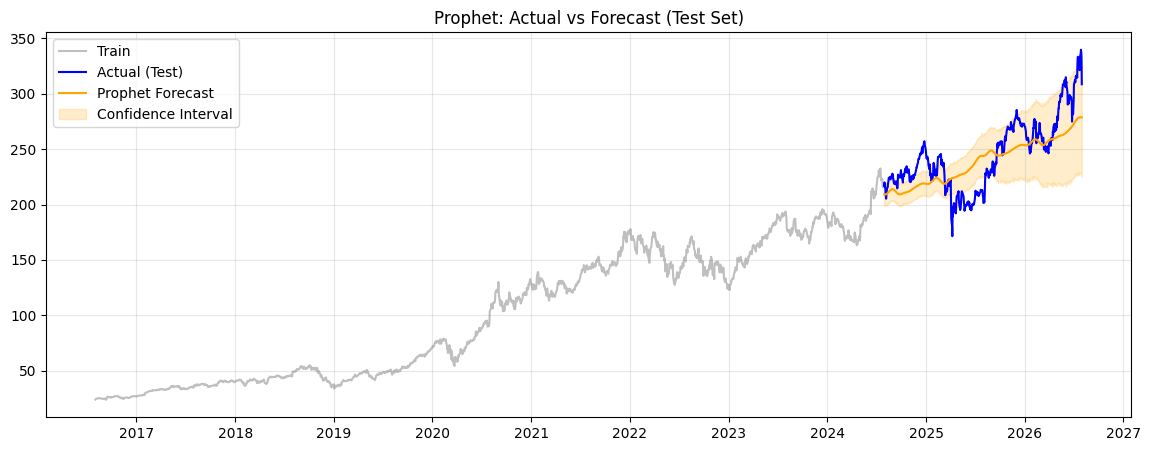

In [37]:
plt.figure(figsize=(14,5))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Train", color="grey", alpha=0.5)
plt.plot(prophet_test["ds"], prophet_test["y"], label="Actual (Test)", color="blue")
plt.plot(prophet_test["ds"], prophet_forecast["yhat"], label="Prophet Forecast", color="orange")
plt.fill_between(prophet_test["ds"], prophet_forecast["yhat_lower"], prophet_forecast["yhat_upper"],
                  color="orange", alpha=0.2, label="Confidence Interval")
plt.title("Prophet: Actual vs Forecast (Test Set)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Model comparison -** Same test set, same scale all models included

In [38]:
comparison_df = pd.DataFrame(results).T.sort_values("RMSE")
comparison_df

,MAE,RMSE,MAPE (%)
Naive Baseline,2.906699,4.290959,1.203868
LSTM,16.590480,20.724147,6.422565
Prophet,18.880847,22.630592,7.753139
ARIMA,19.025504,24.593294,7.735174
SARIMAX,19.025504,24.593294,7.735174


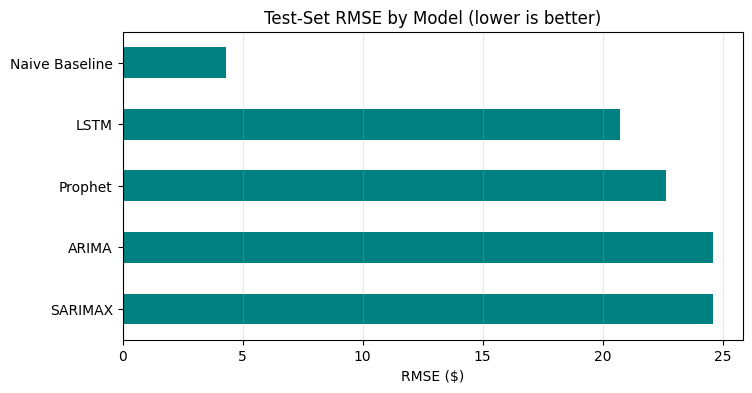

In [39]:
comparison_df["RMSE"].plot(kind="barh", figsize=(8,4), color="teal")
plt.title("Test-Set RMSE by Model (lower is better)")
plt.xlabel("RMSE ($)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis="x")
plt.show()

**Models retrain on full data for deployment**

We refit LSTM and Prophet on the entire dataset (train+test combined) so the deployed models use every available day of real data and can genuinely forecast beyond 2026-08-02.

In [40]:
full_close = raw[["Close"]].values

# Full-data scaler -- this is the one that ships with the deployed LSTM

scaler_full = MinMaxScaler(feature_range=(0,1))
full_scaled = scaler_full.fit_transform(full_close)

X_full, y_full = create_sequences(full_scaled, N_STEPS)

val_cut_full = int(len(X_full) * 0.9)
X_full_tr, X_full_val = X_full[:val_cut_full], X_full[val_cut_full:]
y_full_tr, y_full_val = y_full[:val_cut_full], y_full[val_cut_full:]

X_full_tr  = X_full_tr.reshape((X_full_tr.shape[0], X_full_tr.shape[1], 1))
X_full_val = X_full_val.reshape((X_full_val.shape[0], X_full_val.shape[1], 1))

lstm_production = build_lstm(N_STEPS)
history_full = lstm_production.fit(
    X_full_tr, y_full_tr,
    validation_data=(X_full_val, y_full_val),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
               ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)],
    verbose=1
)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.1011 - val_loss: 0.0646 - learning_rate: 0.0010
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.0455 - val_loss: 0.0387 - learning_rate: 0.0010
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0283 - val_loss: 0.0366 - learning_rate: 0.0010
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0195 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0145 - val_loss: 0.0267 - learning_rate: 0.0010
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0113 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0088 - val_loss: 0.0220 - learning_rate: 0.0010
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0074 - val_loss: 0.0215 - learning_rate: 0.0010
Epoch 9/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0061 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 10/1

In [41]:
# Refit Prophet on the FULL dataset
prophet_full_df = raw.reset_index()[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})
prophet_production = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
prophet_production.fit(prophet_full_df)

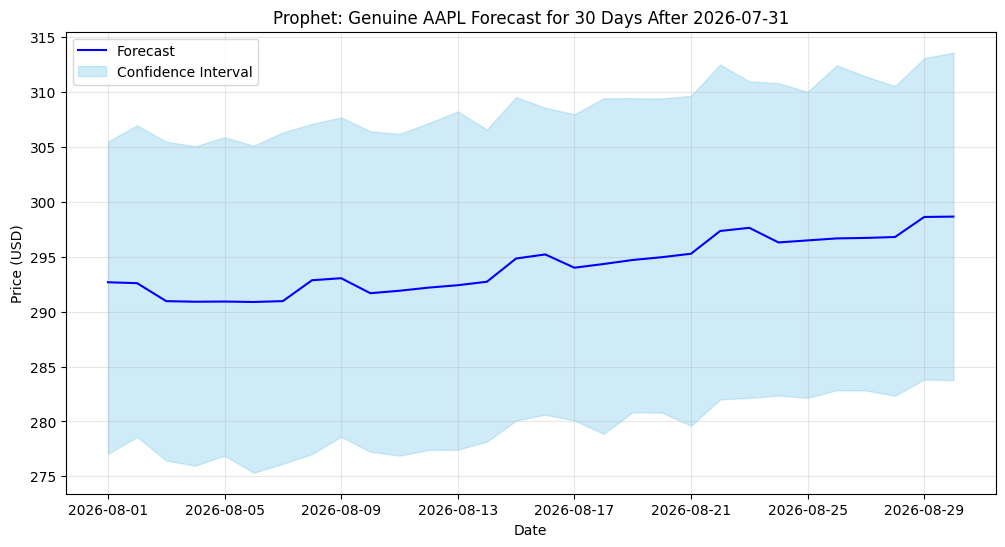

,ds,yhat,yhat_lower,yhat_upper
0,2026-08-01,292.675280,277.045752,305.494415
1,2026-08-02,292.593869,278.594927,306.962936
2,2026-08-03,290.955301,276.433586,305.473354
3,2026-08-04,290.901603,275.977192,305.060327
4,2026-08-05,290.919488,276.881897,305.881306
5,2026-08-06,290.879342,275.326360,305.110202
6,2026-08-07,290.958435,276.142572,306.322261
7,2026-08-08,292.859207,277.031689,307.096702
8,2026-08-09,293.044113,278.610797,307.685652
9,2026-08-10,291.679638,277.241109,306.433092


In [42]:
# Genuine future forecast: next 30 days AFTER the end of the dataset (2026-08-02)
future = prophet_production.make_future_dataframe(periods=30, freq="D", include_history=False)
future_forecast = prophet_production.predict(future)

plt.figure(figsize=(12, 6))
plt.plot(future_forecast["ds"], future_forecast["yhat"], label="Forecast", color="blue")
plt.fill_between(future_forecast["ds"], future_forecast["yhat_lower"], future_forecast["yhat_upper"],
                  color="skyblue", alpha=0.4, label="Confidence Interval")
plt.title(f"Prophet: Genuine {TICKER} Forecast for 30 Days After {raw.index.max().date()}")
plt.xlabel("Date"); plt.ylabel("Price (USD)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

future_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30)

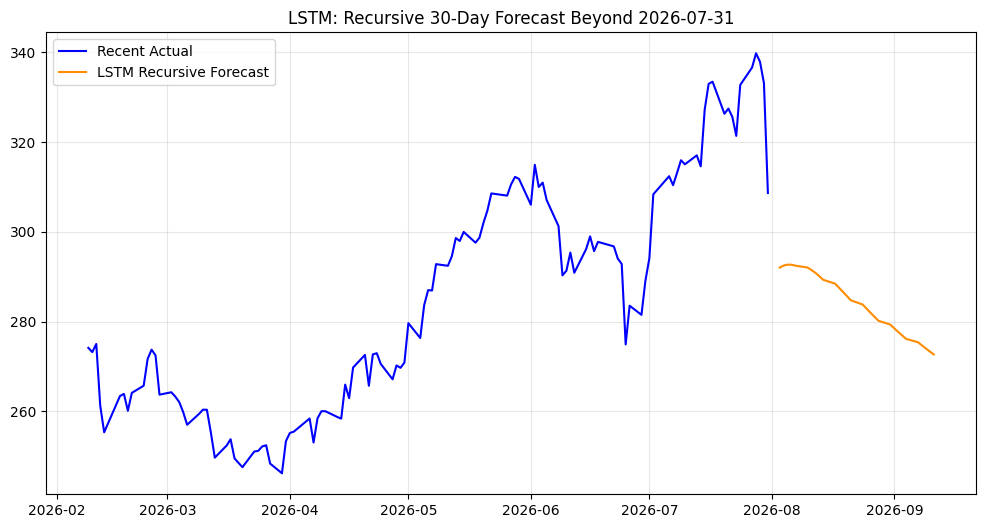

In [43]:
# Genuine recursive multi-day LSTM forecast for the same 30 days beyond the dataset
# (Recursive = each predicted day is fed back in as input for the next day; error compounds
#  with horizon, which is normal and expected -- shown here for the demo, not for scoring.)
n_future_days = 30
last_sequence = full_scaled[-N_STEPS:].copy()
future_preds_scaled = []

for _ in range(n_future_days):
    inp = last_sequence.reshape(1, N_STEPS, 1)
    next_pred = lstm_production.predict(inp, verbose=0)
    future_preds_scaled.append(next_pred[0, 0])
    last_sequence = np.append(last_sequence[1:], next_pred, axis=0)

future_preds_dollars = scaler_full.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1)).flatten()
future_dates = pd.date_range(raw.index.max(), periods=n_future_days + 1, freq="B")[1:]

plt.figure(figsize=(12, 6))
plt.plot(raw.index[-120:], raw["Close"].iloc[-120:], label="Recent Actual", color="blue")
plt.plot(future_dates, future_preds_dollars, label="LSTM Recursive Forecast", color="darkorange")
plt.title(f"LSTM: Recursive {n_future_days}-Day Forecast Beyond {raw.index.max().date()}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Save production artifacts for deployment**

In [44]:
dump(scaler_full, "scaler.joblib")
lstm_production.save("lstm_model.keras")
dump(prophet_production, "fb_prophet_model.joblib")

metadata = {
    "ticker": TICKER,
    "n_steps": N_STEPS,
    "trained_through": str(raw.index.max().date()),
    "data_start": str(raw.index.min().date())
}
with open("model_metadata.json", "w") as f:
    json_lib.dump(metadata, f, indent=2)

print("Saved: scaler.joblib, lstm_model.keras, fb_prophet_model.joblib, model_metadata.json")

Saved: scaler.joblib, lstm_model.keras, fb_prophet_model.joblib, model_metadata.json


In [ ]:
from google.colab import files

for fname in ["scaler.joblib", "lstm_model.keras", "fb_prophet_model.joblib", "model_metadata.json"]:
    files.download(fname)